# OptiVest Explainability and Scenario Walkthrough

This notebook runs the production optimizer on the live 49-stock covariance cache, converts its numerical evidence into real decision narratives, exposes binding-constraint sensitivity insights, and re-solves the same problem under a 20% beta-scaled market-crash shock. The demonstration is deliberately non-persistent.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import select, func, and_
from sqlalchemy.ext.asyncio import async_sessionmaker

REPO_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "backend" / "app").is_dir()
)
BACKEND_ROOT = REPO_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))
os.chdir(BACKEND_ROOT)

from app.core.config import get_settings
from app.db.session import create_engine

SETTINGS = get_settings()
ENGINE = create_engine()
SessionLocal = async_sessionmaker(ENGINE, expire_on_commit=False, autoflush=False)

sns.set_theme(style="whitegrid", context="notebook")
OPTIVEST = {"navy": "#14213D", "teal": "#00A896", "gold": "#FCA311", "red": "#D1495B"}
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Repository: {REPO_ROOT}")
print(f"Database configured by app.core.config: {SETTINGS.database_url.split('@')[-1]}")

Repository: P:\Placement\Projects\Github Projects\IT\OR-OptiVest
Database configured by app.core.config: localhost:5433/optivest


## Reconstruct the live problem without writing a demo run

Model inputs come from the latest real 49-stock covariance cache and constraint settings from the latest solved run. Reading the cache avoids invoking its write-through path, preserving the notebook's read-only contract.

In [2]:
from app.db.models import CovarianceCache, OptimizationRun, Sector, Stock, StockFundamental
from app.explainability.service import build_explanations
from app.optimization.engine import solve
from app.optimization.types import OptimizationInput, SolverName
from app.scenarios.service import run_scenario
from app.scenarios.types import ScenarioType
from app.services.problem_service import decode_constraint_config

async with SessionLocal() as session:
    caches = (await session.scalars(
        select(CovarianceCache)
        .where(CovarianceCache.lookback_days == SETTINGS.covariance_lookback_days)
        .order_by(CovarianceCache.as_of_date.desc(), CovarianceCache.computed_at.desc())
    )).all()
    real_cache = next(cache for cache in caches if len(cache.matrix.get("symbols", [])) == 49)
    latest_run = await session.scalar(
        select(OptimizationRun)
        .where(OptimizationRun.status == "solved")
        .order_by(OptimizationRun.run_at.desc())
        .limit(1)
    )
    assert latest_run is not None
    stock_sector_rows = (await session.execute(
        select(Stock.symbol, Sector.name)
        .join(Sector, Sector.id == Stock.sector_id)
        .where(Stock.symbol.in_(tuple(real_cache.matrix["symbols"])))
    )).all()
    latest_dates = (
        select(StockFundamental.stock_id.label("stock_id"), func.max(StockFundamental.as_of_date).label("as_of_date"))
        .group_by(StockFundamental.stock_id)
        .subquery()
    )
    beta_rows = (await session.execute(
        select(Stock.symbol, StockFundamental.beta)
        .join(latest_dates, latest_dates.c.stock_id == Stock.id)
        .join(StockFundamental, and_(StockFundamental.stock_id == latest_dates.c.stock_id, StockFundamental.as_of_date == latest_dates.c.as_of_date))
        .where(Stock.symbol.in_(tuple(real_cache.matrix["symbols"])))
    )).all()

symbols = tuple(real_cache.matrix["symbols"])
sectors_by_symbol = dict(stock_sector_rows)
beta_by_symbol = {symbol: (float(beta) if beta is not None else 1.0) for symbol, beta in beta_rows}
config = decode_constraint_config(latest_run.sector_constraints)
try:
    selected_solver = SolverName(latest_run.solver_used)
except ValueError:
    selected_solver = SolverName.AUTO
problem = OptimizationInput(
    symbols=symbols,
    expected_returns=np.asarray(real_cache.matrix["expected_returns"], dtype=float),
    covariance=np.asarray(real_cache.matrix["covariance"], dtype=float),
    sectors=tuple(sectors_by_symbol[symbol] for symbol in symbols),
    budget=float(latest_run.budget),
    target_return=float(latest_run.target_return) if latest_run.target_return is not None else None,
    risk_tolerance=float(latest_run.risk_tolerance) if latest_run.risk_tolerance is not None else None,
    max_single_weight=float(latest_run.max_single_weight),
    sector_caps=config["caps"],
    default_sector_cap=config["default_sector_cap"],
    min_holdings=config["min_holdings"],
    max_holdings=config["max_holdings"],
    min_lot_weight=config["min_lot_weight"],
    historical_returns=np.asarray(real_cache.matrix["historical_returns"], dtype=float),
    solver=selected_solver,
    risk_free_rate=config["risk_free_rate"],
)
print(f"Live problem: {len(symbols)} stocks, cache as-of {real_cache.as_of_date}, solver policy {selected_solver.value}")
print(f"Latest beta coverage: {sum(beta is not None for _, beta in beta_rows)}/{len(symbols)} stocks; missing values use the documented neutral fallback of 1.0.")

Live problem: 49 stocks, cache as-of 2026-01-30, solver policy SciPy
Latest beta coverage: 48/49 stocks; missing values use the documented neutral fallback of 1.0.


## Real holdings and generated “Why?” narratives

These texts are returned by `build_explanations()` from the production explainability layer. They are not notebook-authored placeholder descriptions.

In [3]:
base_result = solve(problem)
assert base_result.is_feasible, base_result.message
base_explanations = build_explanations(base_result)
holdings_df = pd.DataFrame([
    {
        "symbol": item.symbol,
        "weight": base_result.weights[item.symbol],
        "decision_reason": item.primary_reason.value,
        "binding_constraint": item.binding_constraint,
        "narrative_text": item.narrative_text,
    }
    for item in base_explanations.included
]).sort_values("weight", ascending=False)
display(holdings_df.style.format({"weight": "{:.2%}"}))
print(base_explanations.summary)
print(f"Expected return: {base_result.expected_return:.2%}; expected volatility: {base_result.expected_volatility:.2%}")

,symbol,weight,decision_reason,binding_constraint,narrative_text
1,BPCL,20.00%,high_risk_adjusted_return,None,BPCL was selected for its 41.0% expected return with an efficient risk contribution; its diversification effect changes portfolio risk by -21.13%.
4,SBIN,20.00%,high_risk_adjusted_return,C4 Sector cap: Financials,SBIN was selected for its 40.5% expected return with an efficient risk contribution; its diversification effect changes portfolio risk by -13.20%.
3,HINDALCO,20.00%,high_risk_adjusted_return,C4 Sector cap: Metals,HINDALCO was selected for its 50.5% expected return with an efficient risk contribution; its diversification effect changes portfolio risk by -24.86%.
0,AXISBANK,15.00%,high_risk_adjusted_return,C4 Sector cap: Financials,AXISBANK was selected for its 39.2% expected return with an efficient risk contribution; its diversification effect changes portfolio risk by -11.78%.
5,TATASTEEL,15.00%,high_risk_adjusted_return,C4 Sector cap: Metals,TATASTEEL was selected for its 46.2% expected return with an efficient risk contribution; its diversification effect changes portfolio risk by -20.72%.
2,HEROMOTOCO,10.00%,high_risk_adjusted_return,None,HEROMOTOCO was selected for its 38.5% expected return with an efficient risk contribution; its diversification effect changes portfolio risk by -8.31%.


The portfolio targets an annualized return of 43.0% with 16.5% expected volatility, a moderate-risk profile spread across 4 sectors. Its largest positions are BPCL (20.0%), SBIN (20.0%), HINDALCO (20.0%); these weights reflect the configured return, risk, concentration, and diversification constraints.
Expected return: 43.04%; expected volatility: 16.51%


## Binding constraints: “what would change this?”

Shadow-price insights are local sensitivity statements from the solver. If no material dual is available, the binding constraint report is still shown rather than inventing a counterfactual.

In [4]:
insight_rows = [
    {
        "constraint": insight.constraint_name,
        "shadow_price": insight.shadow_price,
        "assumed_relaxation": insight.assumed_relaxation,
        "projected_objective_change": insight.projected_objective_change,
        "narrative": insight.narrative,
    }
    for insight in base_explanations.constraint_insights
]
if insight_rows:
    display(pd.DataFrame(insight_rows).style.format({"shadow_price": "{:.6f}", "assumed_relaxation": "{:.2%}", "projected_objective_change": "{:.6f}"}))
else:
    binding_rows = [
        {"constraint": report.constraint_name, "slack": report.slack_value, "details": report.details}
        for report in base_result.constraint_reports if report.is_binding
    ]
    display(Markdown("No material shadow-price counterfactual was returned; binding checks are listed below."))
    display(pd.DataFrame(binding_rows))

No material shadow-price counterfactual was returned; binding checks are listed below.

,constraint,slack,details
0,C1 Budget,0.0000,None
1,C2 Non-negativity,0.0000,None
2,C3 Max single-stock weight,0.0000,None
3,C4 Sector cap: Financials,-0.0000,None
4,C4 Sector cap: Metals,0.0000,None


## Market-crash re-solve

The Phase 6 scenario service applies a 20% beta-scaled expected-return shock and raises the full covariance matrix by its configured volatility multiplier. It then calls the optimization engine again and regenerates explanations; it never scales the portfolio value as a shortcut.

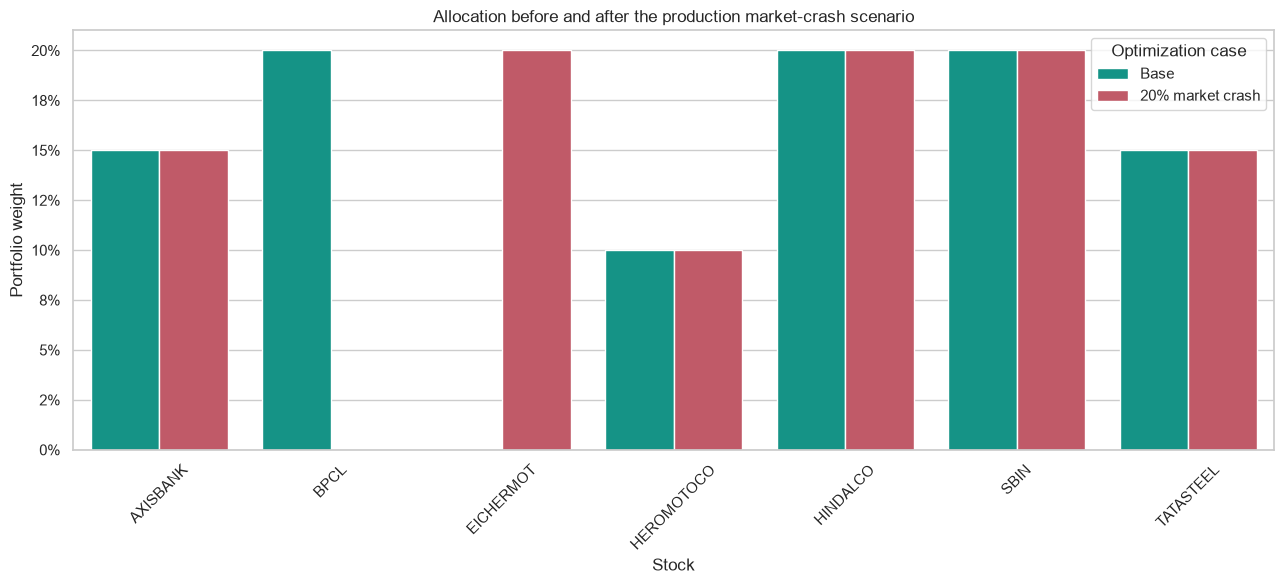

,metric,base,shocked,delta
0,Expected return,0.4304,0.3208,-0.1096
1,Volatility,0.1651,0.1663,+0.0012
2,Sharpe ratio,2.6065,1.9294,-0.6772
3,Diversification score,76.5000,74.5000,-2.0000


,symbol,Base,20% market crash,delta_weight
1,BPCL,20.00%,0.00%,-20.00%
2,EICHERMOT,0.00%,20.00%,+20.00%
3,HEROMOTOCO,10.00%,10.00%,+0.00%
6,TATASTEEL,15.00%,15.00%,+0.00%
4,HINDALCO,20.00%,20.00%,+0.00%
0,AXISBANK,15.00%,15.00%,+0.00%
5,SBIN,20.00%,20.00%,+0.00%


In [5]:
scenario = run_scenario(
    problem,
    ScenarioType.MARKET_CRASH,
    {"delta": -0.20, "betas": [beta_by_symbol.get(symbol, 1.0) for symbol in symbols]},
)
assert scenario.simulated_result.is_feasible and scenario.comparison is not None
allocation_df = pd.DataFrame([
    {
        "symbol": holding.symbol,
        "Base": holding.base_weight,
        "20% market crash": holding.simulated_weight,
        "delta_weight": holding.delta_w,
    }
    for holding in scenario.comparison.holdings
    if holding.base_weight > 1e-6 or holding.simulated_weight > 1e-6
])
allocation_long = allocation_df.melt("symbol", value_vars=["Base", "20% market crash"], var_name="case", value_name="weight")
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=allocation_long, x="symbol", y="weight", hue="case", palette=[OPTIVEST["teal"], OPTIVEST["red"]], ax=ax)
ax.set(title="Allocation before and after the production market-crash scenario", xlabel="Stock", ylabel="Portfolio weight")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Optimization case")
fig.tight_layout()
plt.show()

metrics = scenario.comparison
metric_df = pd.DataFrame([
    {"metric": "Expected return", "base": metrics.base_metrics.expected_return, "shocked": metrics.simulated_metrics.expected_return, "delta": metrics.expected_return_delta},
    {"metric": "Volatility", "base": metrics.base_metrics.volatility, "shocked": metrics.simulated_metrics.volatility, "delta": metrics.volatility_delta},
    {"metric": "Sharpe ratio", "base": metrics.base_metrics.sharpe_ratio, "shocked": metrics.simulated_metrics.sharpe_ratio, "delta": metrics.sharpe_ratio_delta},
    {"metric": "Diversification score", "base": metrics.base_metrics.diversification_score, "shocked": metrics.simulated_metrics.diversification_score, "delta": metrics.diversification_score_delta},
])
display(metric_df.style.format({"base": "{:.4f}", "shocked": "{:.4f}", "delta": "{:+.4f}"}))
display(allocation_df.sort_values("delta_weight", key=abs, ascending=False).style.format({"Base": "{:.2%}", "20% market crash": "{:.2%}", "delta_weight": "{:+.2%}"}))

In [6]:
await ENGINE.dispose()
print("Database engine disposed; no optimization or scenario record was persisted.")

Database engine disposed; no optimization or scenario record was persisted.


## Key takeaway

OptiVest's explanations are deterministic outputs tied to contributions and constraints, not generic investment copy. A scenario changes the statistical inputs, forces a genuine re-optimization, and makes both allocation shifts and portfolio-level consequences inspectable.